Imports and Initialization

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
df = pd.read_csv('train_soil.csv')
test = pd.read_csv('test_soil.csv')

Preliminary Analysis

In [4]:
# see the data #
df.head(5)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [5]:
# find null values, if any #
df.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [6]:
# find duplicates #
df[df.duplicated()]

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need


In [7]:
# understand the data #
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [8]:
Soil_t = df.Soil_Type.value_counts()
Ctype = df.Crop_Type.value_counts()
Cgs = df.Crop_Growth_Stage.value_counts()
Szn = df.Season.value_counts()
IRt = df.Irrigation_Type.value_counts()
MulU = df.Mulching_Used.value_counts()
Region = df.Region.value_counts()
IRNeed = df.Irrigation_Need.value_counts()

Quick EDA

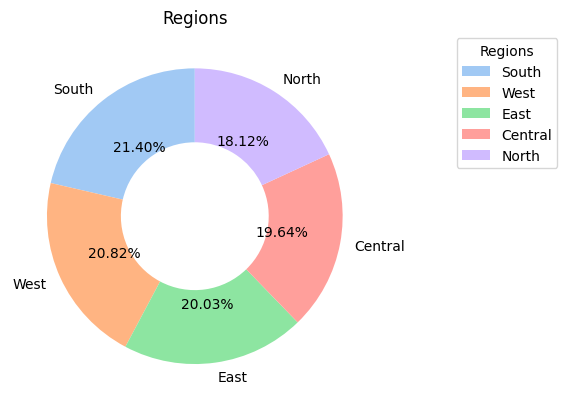

In [9]:
labels_r = Region.index
colors = sns.color_palette('pastel')

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    Region,
    labels=labels_r,
    colors=colors,
    startangle=90,
    autopct='%1.2f%%',
    wedgeprops=dict(width=0.5)
)

ax.legend(wedges, labels_r, title="Regions", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Regions')
plt.show()


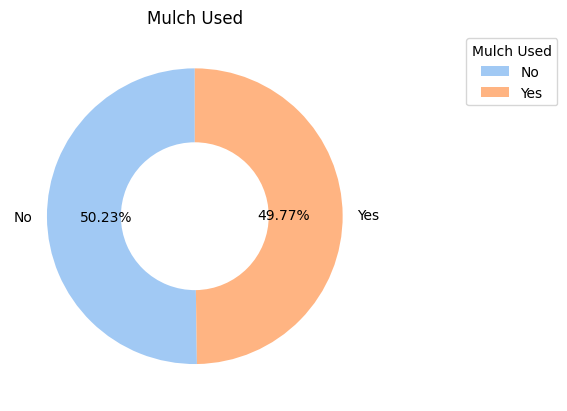

In [10]:
labels_mul = MulU.index
colors = sns.color_palette('pastel')

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    MulU,
    labels=labels_mul,
    colors=colors,
    startangle=90,
    autopct='%1.2f%%',
    wedgeprops=dict(width=0.5)
)

ax.legend(wedges, labels_mul, title="Mulch Used", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Mulch Used')
plt.show()


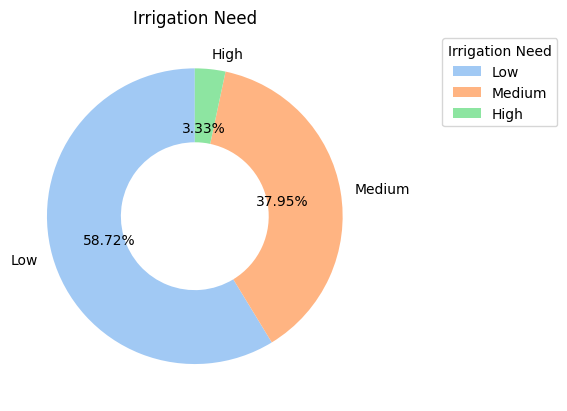

In [11]:
labels_irn = IRNeed.index
colors = sns.color_palette('pastel')

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    IRNeed,
    labels=labels_irn,
    colors=colors,
    startangle=90,
    autopct='%1.2f%%',
    wedgeprops=dict(width=0.5)
)

ax.legend(wedges, labels_irn, title="Irrigation Need", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Irrigation Need')
plt.show()

# data is very imbalanced!! #

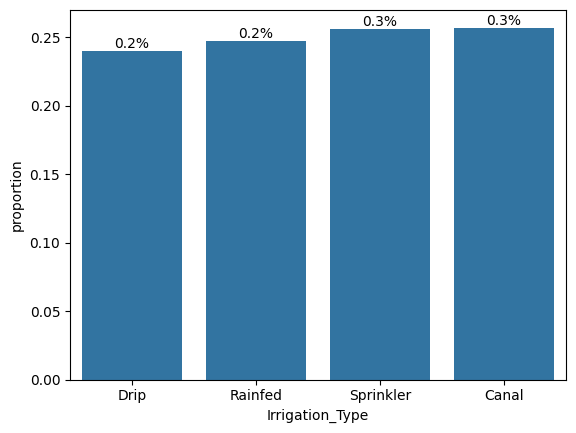

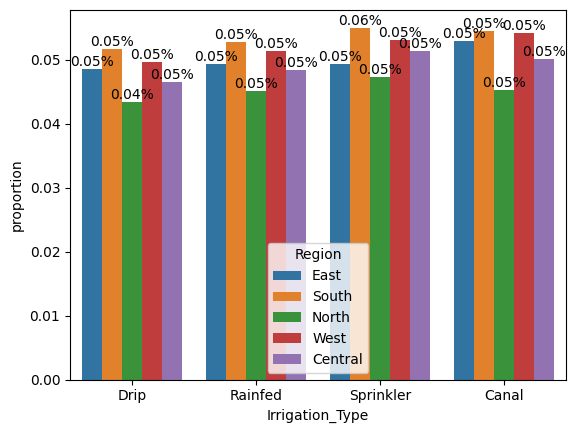

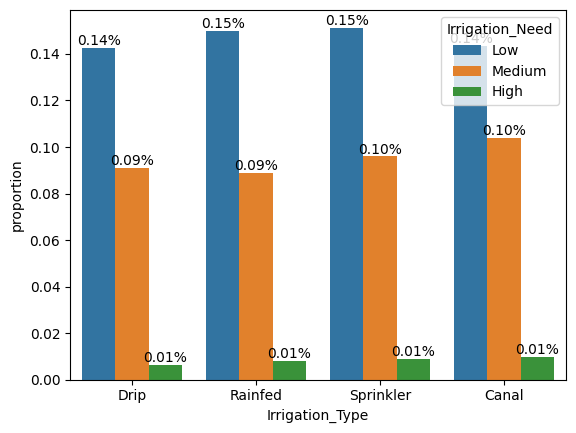

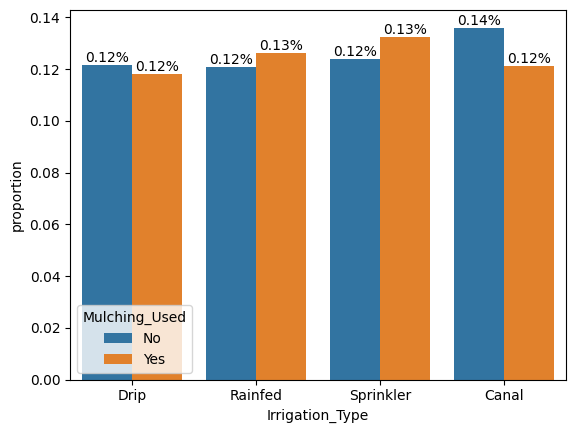

In [12]:
ax1 = sns.countplot(x='Irrigation_Type', stat='proportion', data=df)
ax1.bar_label(ax1.containers[0], fmt='%.1f%%')
plt.show()

ax2 = sns.countplot(x='Irrigation_Type', stat='proportion', hue='Region', data=df)
for cont in ax2.containers:
    ax2.bar_label(cont, fmt='%.2f%%')
plt.show()

ax3 = sns.countplot(x='Irrigation_Type', stat='proportion', hue='Irrigation_Need', data=df)
for cont in ax3.containers:
    ax3.bar_label(cont, fmt='%.2f%%')
plt.show()

ax4 = sns.countplot(x='Irrigation_Type', stat='proportion', hue='Mulching_Used', data=df)
for cont in ax4.containers:
    ax4.bar_label(cont, fmt='%.2f%%')
plt.show()

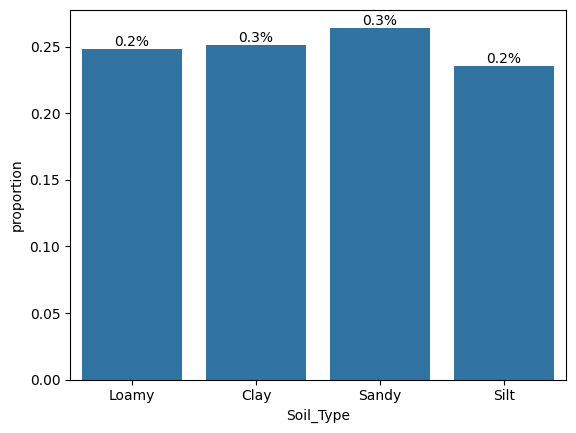

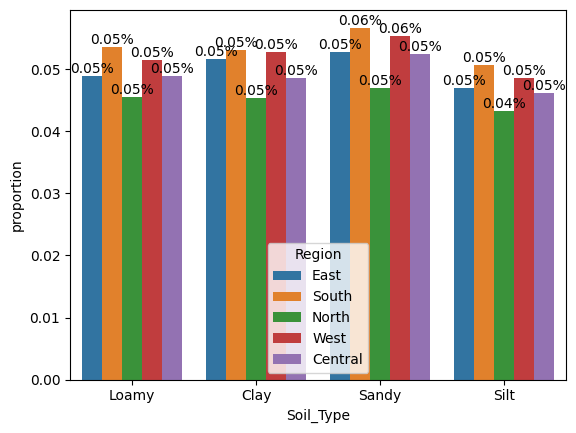

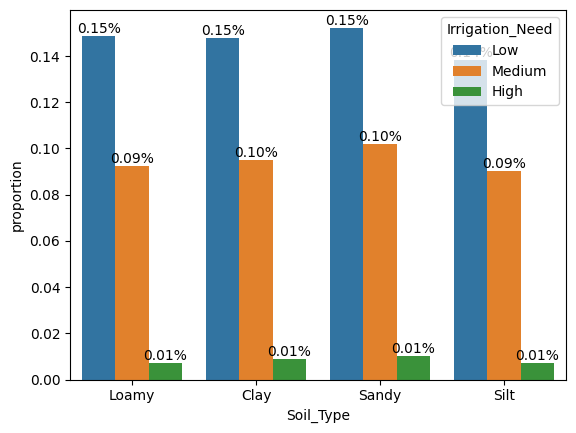

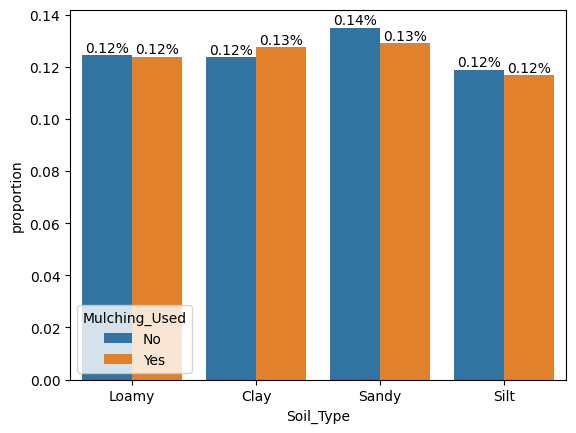

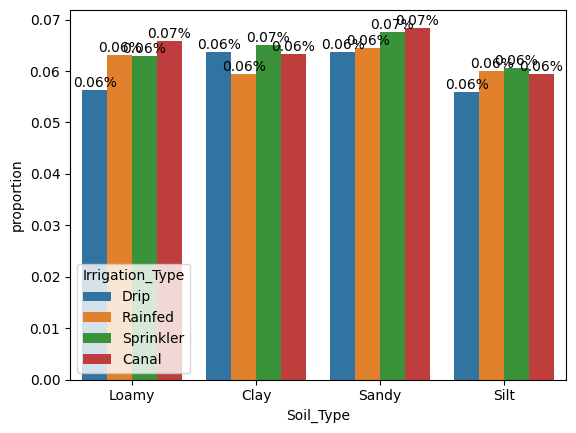

In [13]:
ax1 = sns.countplot(x='Soil_Type', stat='proportion', data=df)
ax1.bar_label(ax1.containers[0], fmt='%.1f%%')
plt.show()

ax2 = sns.countplot(x='Soil_Type', stat='proportion', hue='Region', data=df)
for cont in ax2.containers:
    ax2.bar_label(cont, fmt='%.2f%%')
plt.show()

ax3 = sns.countplot(x='Soil_Type', stat='proportion', hue='Irrigation_Need', data=df)
for cont in ax3.containers:
    ax3.bar_label(cont, fmt='%.2f%%')
plt.show()

ax4 = sns.countplot(x='Soil_Type', stat='proportion', hue='Mulching_Used', data=df)
for cont in ax4.containers:
    ax4.bar_label(cont, fmt='%.2f%%')
plt.show()

ax5 = sns.countplot(x='Soil_Type', stat='proportion', hue='Irrigation_Type', data=df)
for cont in ax5.containers:
    ax5.bar_label(cont, fmt='%.2f%%')
plt.show()

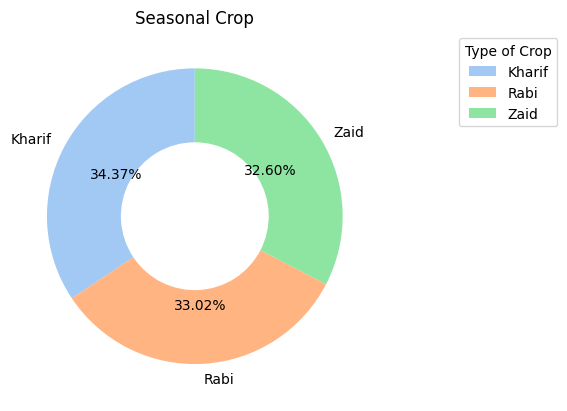

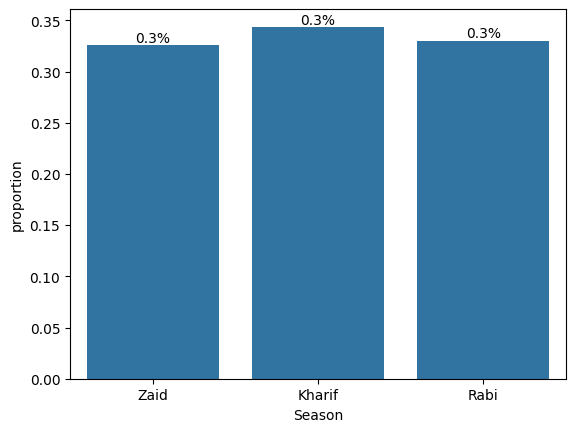

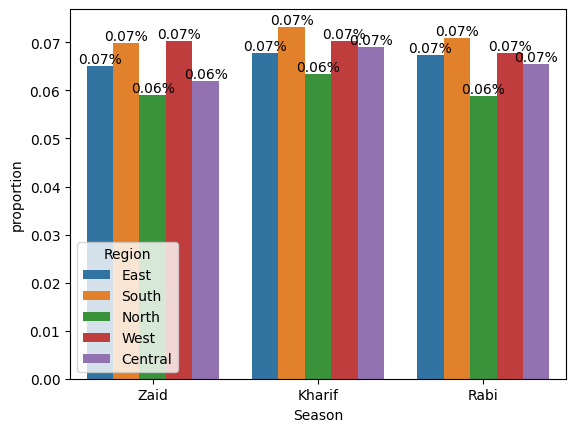

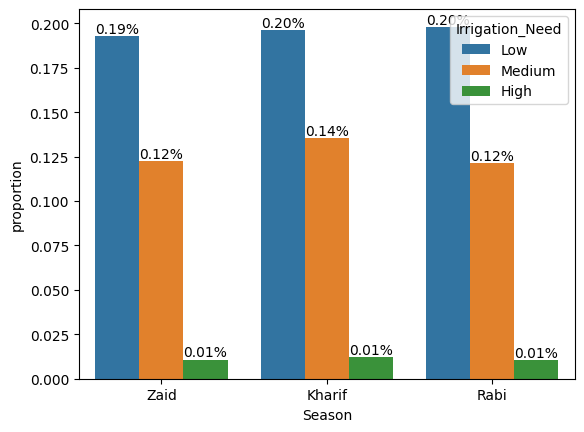

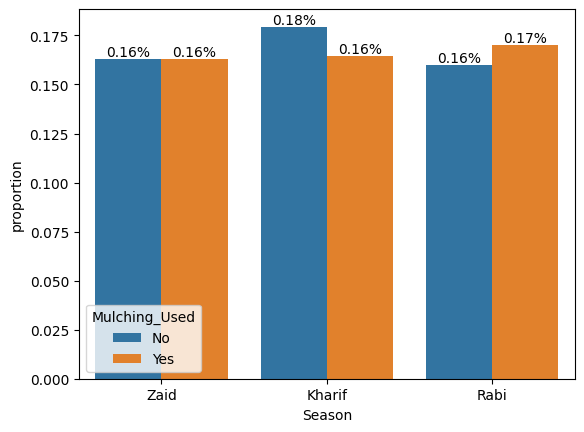

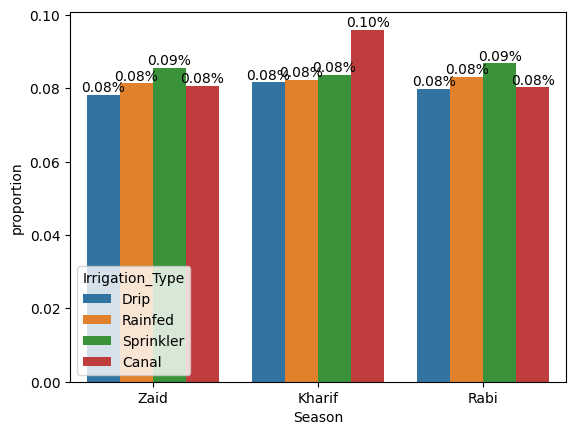

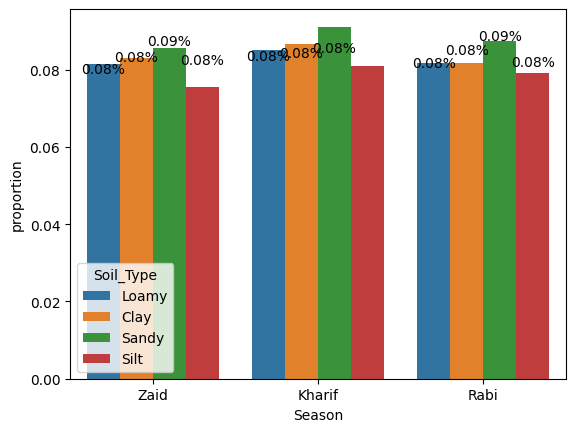

In [14]:
labels_szn = Szn.index
colors = sns.color_palette('pastel')

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    Szn,
    labels=labels_szn,
    colors=colors,
    startangle=90,
    autopct='%1.2f%%',
    wedgeprops=dict(width=0.5)
)

ax.legend(wedges, labels_szn, title="Type of Crop", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Seasonal Crop')
plt.show()

ax1 = sns.countplot(x='Season', stat='proportion', data=df)
ax1.bar_label(ax1.containers[0], fmt='%.1f%%')
plt.show()

ax2 = sns.countplot(x='Season', stat='proportion', hue='Region', data=df)
for cont in ax2.containers:
    ax2.bar_label(cont, fmt='%.2f%%')
plt.show()

ax3 = sns.countplot(x='Season', stat='proportion', hue='Irrigation_Need', data=df)
for cont in ax3.containers:
    ax3.bar_label(cont, fmt='%.2f%%')
plt.show()

ax4 = sns.countplot(x='Season', stat='proportion', hue='Mulching_Used', data=df)
for cont in ax4.containers:
    ax4.bar_label(cont, fmt='%.2f%%')
plt.show()

ax5 = sns.countplot(x='Season', stat='proportion', hue='Irrigation_Type', data=df)
for cont in ax5.containers:
    ax5.bar_label(cont, fmt='%.2f%%')
plt.show()

ax6 = sns.countplot(x='Season', stat='proportion', hue='Soil_Type', data=df)
for cont in ax5.containers:
    ax6.bar_label(cont, fmt='%.2f%%')
plt.show()

Models to deal with imbalanced data

In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

Model 1: Undersample the Majority

In [16]:
high = df[df['Irrigation_Need'] == 'High']
medium = df[df['Irrigation_Need'] == 'Medium']
low = df[df['Irrigation_Need'] == 'Low']

# undersample majority classes to match minority (High at 3%)
n = len(high)
medium_sampled = medium.sample(n, random_state=0)
low_sampled = low.sample(n, random_state=0)

# recombine and shuffle
df_balanced = pd.concat([high, medium_sampled, low_sampled]).sample(frac=1, random_state=0).reset_index(drop=True)


label_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_balanced['Irrigation_Need'] = df_balanced['Irrigation_Need'].map(label_map)

df_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63027 entries, 0 to 63026
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       63027 non-null  int64  
 1   Soil_Type                63027 non-null  object 
 2   Soil_pH                  63027 non-null  float64
 3   Soil_Moisture            63027 non-null  float64
 4   Organic_Carbon           63027 non-null  float64
 5   Electrical_Conductivity  63027 non-null  float64
 6   Temperature_C            63027 non-null  float64
 7   Humidity                 63027 non-null  float64
 8   Rainfall_mm              63027 non-null  float64
 9   Sunlight_Hours           63027 non-null  float64
 10  Wind_Speed_kmh           63027 non-null  float64
 11  Crop_Type                63027 non-null  object 
 12  Crop_Growth_Stage        63027 non-null  object 
 13  Season                   63027 non-null  object 
 14  Irrigation_Type       

In [17]:
df_encoded = pd.get_dummies(df_balanced.drop('id', axis=1), drop_first = True)
df_encoded.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63027 entries, 0 to 63026
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Soil_pH                       63027 non-null  float64
 1   Soil_Moisture                 63027 non-null  float64
 2   Organic_Carbon                63027 non-null  float64
 3   Electrical_Conductivity       63027 non-null  float64
 4   Temperature_C                 63027 non-null  float64
 5   Humidity                      63027 non-null  float64
 6   Rainfall_mm                   63027 non-null  float64
 7   Sunlight_Hours                63027 non-null  float64
 8   Wind_Speed_kmh                63027 non-null  float64
 9   Field_Area_hectare            63027 non-null  float64
 10  Previous_Irrigation_mm        63027 non-null  float64
 11  Irrigation_Need               63027 non-null  int64  
 12  Soil_Type_Loamy               63027 non-null  bool   
 13  S

In [29]:
feat = df_encoded.drop('Irrigation_Need', axis=1)
target = df_encoded['Irrigation_Need']

In [30]:
X_train, X_test, y_train, y_test = train_test_split(feat, target, test_size = 0.3, random_state=0)

In [31]:
Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

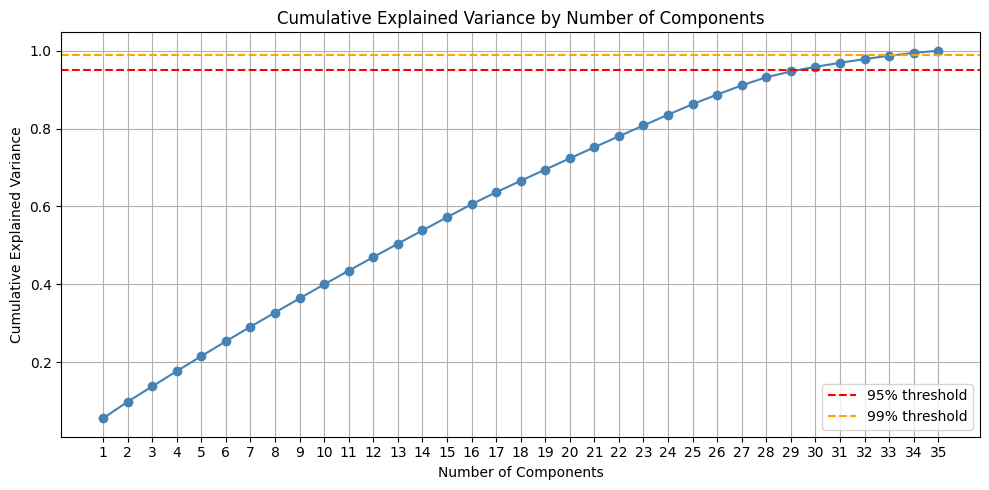

In [32]:
pca_full = PCA(random_state=0)
pca_full.fit(X_train_scaled)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 36), pca_full.explained_variance_ratio_.cumsum(), 
         marker='o', color='steelblue')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')
plt.title('Cumulative Explained Variance by Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.xticks(range(1, 36))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# no significant compression possible #

In [33]:
rf = RandomForestClassifier(n_estimators = 5000, class_weight='balanced', criterion = 'entropy')

In [34]:
rf.fit(X_train_scaled, y_train)
prediction_rf = rf.predict(X_test_scaled)
print(classification_report(y_test,prediction_rf))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6350
           1       0.94      0.96      0.95      6325
           2       0.98      0.94      0.96      6234

    accuracy                           0.97     18909
   macro avg       0.97      0.97      0.97     18909
weighted avg       0.97      0.97      0.97     18909



Model 2: Balanced Random Forest without SMOTE

In [35]:
X = df.drop(columns=['id', 'Irrigation_Need'])
y = df['Irrigation_Need']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)


categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

# Model
pipeline_no_smote = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=1000,
        criterion='entropy',
        class_weight='balanced',
        random_state=0,
        n_jobs=-1
    ))
])

# Train
pipeline_no_smote.fit(X_train, y_train)

# Predict
y_pred_no_smote = pipeline_no_smote.predict(X_test)

print(classification_report(y_test, y_pred_no_smote))

              precision    recall  f1-score   support

        High       0.97      0.90      0.93      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.98      0.98      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



Model 3: Balanced Random Forest and SMOTE

In [37]:
pipeline_smote = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(
        sampling_strategy='not majority',  # safer default
        random_state=42
    )),
    ('model', RandomForestClassifier(
        n_estimators=1000,
        max_depth=None,
        random_state=0,
        n_jobs=-1
    ))
])

# Train
pipeline_smote.fit(X_train, y_train)

# Predict
y_pred_smote = pipeline_smote.predict(X_test)

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

        High       0.96      0.91      0.93      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.98      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



Model 4: xgboost

In [38]:
from xgboost import XGBClassifier

In [87]:
# Reload df fresh to avoid label corruption from earlier sections
df = pd.read_csv('train_soil.csv')
test = pd.read_csv('test_soil.csv')

label_map_xgb = {'Low': 0, 'Medium': 1, 'High': 2}
df['Irrigation_Need'] = df['Irrigation_Need'].map(label_map_xgb)

X_xgb = df.drop(columns=['id', 'Irrigation_Need'])
y_xgb = df['Irrigation_Need']

X_train_x, X_test_x, y_train_x, y_test_x = train_test_split(
    X_xgb, y_xgb,
    test_size=0.2,
    random_state=0,
    stratify=y_xgb
)


categorical_features = X_train_x.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train_x.select_dtypes(include=['number']).columns.tolist()

In [88]:
# Pipeline
pipeline_xgb = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(
        objective='multi:softprob',
        num_class=3,
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    ))
])

# Train
pipeline_xgb.fit(X_train_x, y_train_x)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The giv

In [89]:
y_pred_xgb = pipeline_xgb.predict(X_test_x)
print(classification_report(y_test_x, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     73983
           1       0.98      0.97      0.98     47815
           2       0.97      0.92      0.94      4202

    accuracy                           0.98    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.98      0.98      0.98    126000



Preparing Submission

In [44]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [45]:
test.drop('id', axis=1, inplace=True)
test.head(5)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


In [49]:
pred_xgb = pipeline_xgb.predict(test)

In [58]:
submission_x = pd.DataFrame(pred_xgb)

submission_x[0] = submission_x[0].map({0: 'Low', 1: 'Medium', 2: 'High'})
submission_x = submission_x.rename(columns={"0": "Irrigation_Need"})

submission_x.index = range(630000, 630000 + len(submission_x))
submission_x.index.name = "id"

submission_x.head(5)

,0
id,
630000,Low
630001,Low
630002,Low
630003,Low
630004,Low


In [ ]:
submission_x.to_csv('Submit_xgboost.csv')

In [71]:
pred_rf = pipeline_no_smote.predict(test)

array(['Low', 'Low', 'Low', ..., 'Medium', 'Low', 'Medium'],
      shape=(270000,), dtype=object)

In [74]:
submission_rf = pd.DataFrame(pred_rf)

submission_rf = submission_rf.rename(columns={"0": "Irrigation_Need"})

submission_rf.index = range(630000, 630000 + len(submission_rf))
submission_rf.index.name = "id"

submission_rf.head(5)

,0
id,
630000,Low
630001,Low
630002,Low
630003,Low
630004,Low


In [ ]:
submission_rf.to_csv('Submit_rf.csv')


In [90]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    'Model': [
        'Balanced RF (no SMOTE)',
        'Balanced RF + SMOTE',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_no_smote),
        accuracy_score(y_test, y_pred_smote),
        accuracy_score(y_test_x, y_pred_xgb)
    ]
}).sort_values('Accuracy', ascending=False)

print(results.to_string(index=False))

                 Model  Accuracy
Balanced RF (no SMOTE)  0.984873
   Balanced RF + SMOTE  0.984484
               XGBoost  0.984357
